In [201]:
import math
import random
import numpy as np

In [297]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | %.4f }" % (n.label, n.data,n._grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [262]:
class Value():
    def __init__(self,value,_children=(),_op="", label=""):
        self.data=value
        self.label=label
        self._prev=set(_children)
        self._op=_op
        self._grad=0.0
        self._backward=lambda:None
        
    def __repr__(self):
        return f"Value(data={self.data},{self.label})"
    
    def __add__(self,other):
        other = Value(other) if not isinstance(other,Value) else other
        out = Value(self.data+other.data,(self,other),"+")
        def _backward():
            self._grad += 1.0 * out._grad
            other._grad += 1.0 * out._grad
        out._backward=_backward
        return out
        
    def __mul__(self,other):
        other = Value(other) if not isinstance(other,Value) else other
        out = Value(self.data*other.data,(self,other),"*")
        
        def _backward():
            self._grad += other.data * out._grad
            other._grad += self.data * out._grad
        out._backward=_backward
        return out

    def __pow__(self,val):
        assert isinstance(val, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**val,(self,),f"**{val}")
        
        def _backward():
            self._grad += (val*(self.data**(val-1))) * out._grad
        out._backward=_backward
        return out
        
    def relu(self):
        out = Value(max(0,self.data),(self,),"relu")
        
        def _backward():
            self._grad += (0 if self.data<=0 else 1) * out._grad
        out._backward=_backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self._grad += (1-(out.data**2)) * out._grad
        out._backward=_backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
          self.grad += out.data * out.grad
        out._backward = _backward
        return out


    def backward(self):
        nodes=[]
        visited=set([])
        def recc(node):
            if node in visited:
                return
            visited.add(node)
            for i in node._prev:
                recc(i)
            nodes.append(node)
        recc(self)
        self._grad=1.0
        for i in nodes[::-1]:
            i._backward()
        return
    def __sub__(self,other):
        return self.__add__(-(other))

    def __rsub__(self,other):
        return self.__add__(-(other))
        
    def __radd__(self,other):
        return self.__add__(other)

    def __rmul__(self,other):
        return self.__mul__(other)

    def __neg__(self):
        return self * (-1)

    def __truediv__(self, other): 
        return self * other**-1

In [263]:
a=Value(2)
b=3
c= b*a
c,c._prev

(Value(data=6,), {Value(data=2,), Value(data=3,)})

Value(data=3,)
Value(data=6,)
Value(data=2,)


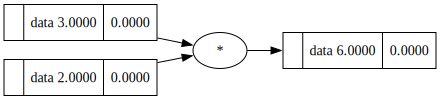

In [111]:
draw_dot(c)

In [67]:
c._backward()

In [179]:
x1=Value(3,label='x1')
w1=Value(2,label='w1')
x2=Value(1,label='x2')
w2=Value(-3,label='w2')
b=Value(3,label='b')
w1x1=x1*w1
w2x2=x2*w2
n=w1x1+w2x2
out = n*b
w1x1.label='w1x1'
w2x2.label='w2x2'
n.label='w1x1+w2x2'
out.label='w1x1+w2x2+b'


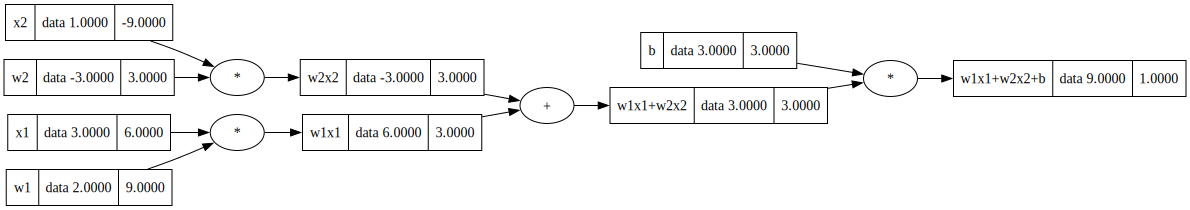

In [182]:
draw_dot(out)

In [176]:
out._grad=1

In [181]:
out.backward()

In [140]:
n._backward()

In [141]:
w1x1._backward()

In [142]:
w2x2._backward()

In [319]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p._grad=0.0

    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, n, activation=True):
        self.weights = [Value(random.uniform(-1,1)) for _ in range(n)]
        self.bias = Value(random.uniform(-1,1))
        self.activation = activation
    def __call__(self, inputs):
        out = sum((w*x for w,x in zip(self.weights,inputs)),self.bias)
        acti = out.tanh() if self.activation else out
        return acti

    def parameters(self):
        return self.weights + [self.bias]

class Layer(Module):
    def __init__(self, nin, nout, final_layer=False):
        self.neurons = [Neuron(nin,final_layer) for _ in range(nout)]

    def __call__(self, inputs):
        outs = [n(inputs) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class Network(Module):
    def __init__(self, nin, nout):
        n = [nin]+nout
        self.layers = [Layer(n[i],n[i+1],final_layer=i!=len(nout)-1) for i in range(len(n)-1)]

    def __call__(self, inputs):
        for layer in self.layers:
            inputs=layer(inputs)
        return inputs

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [356]:
n = Network(3, [4, 4, 1])

In [357]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [358]:
for i in range(50):
    yout = [n(x) for x in xs]
    loss = sum(((yo-yd)**2 for yo,yd in zip(yout,ys)))
    n.zero_grad()
    loss.backward()
    print(i, loss.data)
    for p in n.parameters():
        p.data += (-0.05) * p._grad

0 9.61440874748463
1 4.258777017497806
2 1.64639120803493
3 0.5948499209096496
4 0.2152760857550371
5 0.09472639556078849
6 0.059517090801253475
7 0.04415329330526396
8 0.035862189896298316
9 0.030709271007261868
10 0.0273084296484596
11 0.024933995183243796
12 0.023185457242146608
13 0.0218301621585856
14 0.020728571912738546
15 0.019797737055553974
16 0.01898631780090657
17 0.018262769263157452
18 0.01760676160340184
19 0.017005055583171655
20 0.01644853953659488
21 0.015930759101506174
22 0.015446881958656247
23 0.014993162972107127
24 0.0145665715670702
25 0.014164588312215872
26 0.013785062130511914
27 0.013426125963994912
28 0.01308613572220809
29 0.012763630345925737
30 0.012457301417621119
31 0.012165971056068432
32 0.01188857417915841
33 0.01162414446493791
34 0.01137180261111342
35 0.0111307465297073
36 0.010900242926133317
37 0.01067962005165178
38 0.010468261379406096
39 0.010265600071430025
40 0.010071114103207511
41 0.00988432195676069
42 0.009704778800195914
43 0.0095320

In [359]:
n(xs[1])

Value(data=-1.0000539941829674,)